In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

pd.set_option('display.max_columns', 200)

In [2]:
#importing day_csv data

day_csv = "data/day.csv"
day_df= pd.read_csv(day_csv)

DAY_CSV DATA UNDERSTANDING

In [ ]:
day_df.shape

In [ ]:
day_df.dtypes

In [ ]:
day_df.describe

In [ ]:
day_df.columns

In [ ]:
day_df.head(20)

In [ ]:
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [9]:
#importing hour_csv data
hour_csv = "data/hour.csv"
hour_df = pd.read_csv(hour_csv)

HOUR_CSV DATA UNDERSTANDING

In [ ]:
hour_df.shape

In [ ]:
hour_df.dtypes

In [ ]:
hour_df.describe

In [ ]:
hour_df.columns

In [14]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [11]:
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

DATA CLEANING

In [39]:
#no duplicated values
print(f'Valores duplicados en day_csv: {day_df.duplicated().sum()}')
print(f'Valores duplicados en hour_csv: {hour_df.duplicated().sum()}')

Valores duplicados en day_csv: 0
Valores duplicados en hour_csv: 0


In [ ]:
#transforming dteday into datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
display(day_df['dteday'].describe())
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
display(hour_df['dteday'].describe())

In [15]:
#renaming columns and dropping somes
day_df.rename(columns={'dteday':'date',
                       'weathersit':'weather',
                       'yr':'year',
                       'mnth':'month',
                       'cnt':'rented_bikes'
                       })

,instant,date,season,year,month,holiday,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,rented_bikes
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [17]:
hour_df.rename(columns={'dteday':'date',
                       'weathersit':'weather',
                       'yr':'year',
                       'mnth':'month',
                       'cnt':'rented_bikes',
                       'hr':'hour'
                       })

,instant,date,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,rented_bikes
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [ ]:
#MISSING VALUES

In [ ]:
#we create a general configuration for our graphics
sns.set_theme (
    style = 'darkgrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)

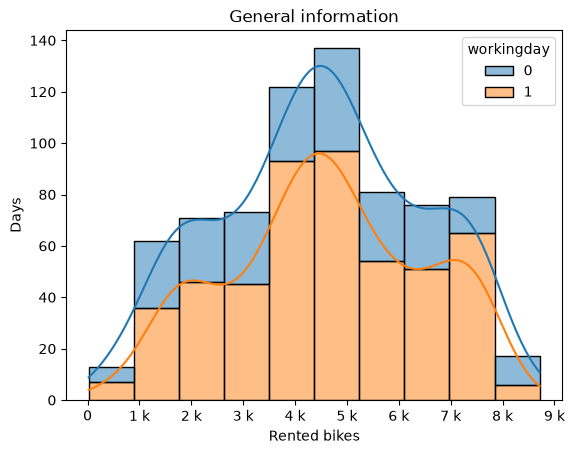

In [27]:
#first, histogram

sns.histplot(data=day_df, x='cnt', bins=10, hue='workingday', multiple='stack', kde=True)
plt.xticks(range(0, 10000, 1000))

ax = plt.gca() # Recupera el gráfico actual
ax.xaxis.set_major_formatter(ticker.EngFormatter())

plt.title('General information')
plt.xlabel('Rented bikes')
plt.ylabel('Days')
plt.show()

In [ ]:
#searching for outliners



In [ ]:
#hour.csv . 0-23 fila forman una fila de la tabla de day (evidentemente, un día tiene 24 horas)
#weathersit: 1-despejado 2-niebla 3-lluvia débil 4-tormenta



In [ ]:
#Análisis exploratorio de los datos
#hay horas faltantes en el dataset. 

import pandas as pd

# 1. Creamos una columna 'datetime' combinando el día y la hora
# (Esto junta "2011-01-01" y la hora 3 en un único dato: "2011-01-01 03:00:00")
hour_df['datetime'] = pd.to_datetime(hour_df['dteday']) + pd.to_timedelta(hour_df['hr'], unit='h')

# 2. Generamos el rango teórico perfecto de horas (desde el primer minuto al último)
rango_teorico = pd.date_range(
    start=hour_df['datetime'].min(), 
    end=hour_df['datetime'].max(), 
    freq='h' # 'h' significa frecuencia horaria
)

# 3. Restamos a nuestro "calendario perfecto" las horas que sí tenemos registradas
horas_faltantes = rango_teorico.difference(hour_df['datetime'])

# --- MOSTRAR RESULTADOS ---
print(f"Total de horas faltantes detectadas: {len(horas_faltantes)}")
print("\nPrimeras 10 horas perdidas en el dataset:")
display(horas_faltantes[:10])


In [ ]:
#Definición de la serie temporal. Gráficos que demuestren la temporalidad. Buscar tendencia y estacionalidad.


In [ ]:
#Transformaciones de la serie